In [ ]:
# Importação das bibliotecas
import pandas as pd
import hashlib
import requests
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
import pickle
import joblib


In [ ]:
# 1. Carregamento e Validação do Dataset
# URL do dataset
url = 'https://raw.githubusercontent.com/norisjunior/FIAPML/refs/heads/main/datasets/dataset-Sprint3-acidentes.csv'
# Hash fornecido para validação
hash_esperado = '47dd04afa03183b74af07a22284b473d9f5b6c1da4b3fecd1421b8feff8fcfa6'

In [ ]:
# Baixando o conteúdo do arquivo
try:
    response = requests.get(url)
    response.raise_for_status()  # Verifica se o request foi bem sucedido
    conteudo_arquivo = response.content

    # Calculando o hash do conteúdo baixado
    hash_calculado = hashlib.sha256(conteudo_arquivo).hexdigest()

    # Validando o hash
    if hash_calculado == hash_esperado:
        print("Validação do hash bem-sucedida! Os hashes conferem.")
        # Carregando o dataset em um DataFrame
        from io import StringIO
        df = pd.read_csv(StringIO(conteudo_arquivo.decode('utf-8')))
        print("\nDataset carregado com sucesso!")
        print("Shape do dataset:", df.shape)
        print("\nPrimeiras 5 linhas do dataset:")
        print(df.head())
    else:
        print("Erro na validação do hash! Os hashes não conferem.")
        print(f"Hash esperado: {hash_esperado}")
        print(f"Hash calculado: {hash_calculado}")

except requests.exceptions.RequestException as e:
    print(f"Erro ao baixar o arquivo: {e}")

Validação do hash bem-sucedida! Os hashes conferem.

Dataset carregado com sucesso!
Shape do dataset: (50000, 13)

Primeiras 5 linhas do dataset:
      dia_semana      br     km     fase_dia  sentido_via  \
0        domingo  BR-365  361.7    Pleno dia    Crescente   
1        domingo  BR-101  723.0    Pleno dia  Decrescente   
2        domingo  BR-116  284.0  Plena Noite  Decrescente   
3  segunda-feira  BR-277  116.0    Pleno dia  Decrescente   
4   quarta-feira  BR-290   55.3  Plena Noite    Crescente   

  condicao_metereologica tipo_pista tracado_via  latitude  longitude  \
0              Céu Claro    Simples       Curva -18.50801  -46.12129   
1              Céu Claro    Simples        Reta -16.40793  -39.58786   
2              Céu Claro      Dupla        Reta -23.69998  -46.86777   
3              Céu Claro      Dupla        Reta -25.44728  -49.50939   
4              Céu Claro   Múltipla        Reta -29.91340  -50.80843   

  delegacia classificacao_acidente postos_policiais_PR


--- Análise Exploratória de Dados (EDA) ---


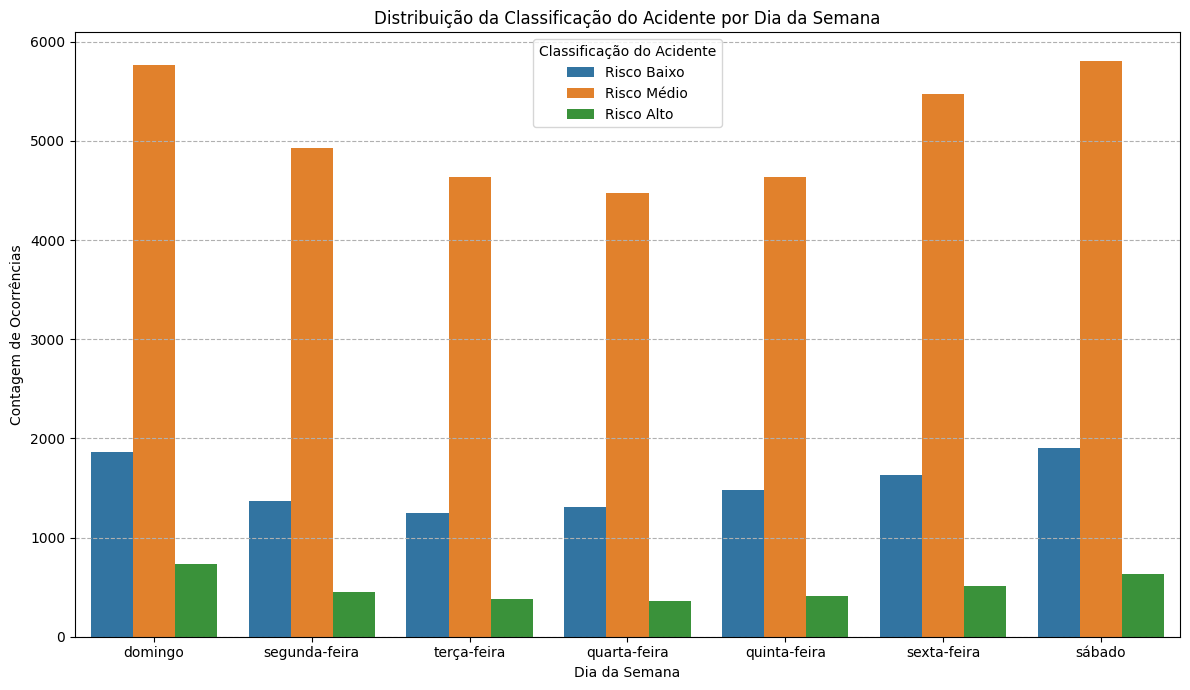


Insight: O gráfico nos permite visualizar se há dias da semana com maior incidência de acidentes de um determinado risco.


In [ ]:
# 2. Análise Exploratória de Dados (EDA) e Insights

# O DataFrame 'df' já foi carregado e validado.
# A coluna 'classificacao_acidente' será nossa variável alvo (target).

print("\n--- Análise Exploratória de Dados (EDA) ---")
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='dia_semana', hue='classificacao_acidente',
              order=['domingo', 'segunda-feira', 'terça-feira', 'quarta-feira', 'quinta-feira', 'sexta-feira', 'sábado'],
              hue_order=['Risco Baixo', 'Risco Médio', 'Risco Alto']) # Opcional: para ordenar a legenda
plt.title('Distribuição da Classificação do Acidente por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Contagem de Ocorrências')
plt.legend(title='Classificação do Acidente')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

print("\nInsight: O gráfico nos permite visualizar se há dias da semana com maior incidência de acidentes de um determinado risco.")

In [ ]:
# 3. Pipeline de Machine Learning (Pré-processamento)

# Separando features (X) e target (y)
X = df.drop('classificacao_acidente', axis=1) # Usamos todas as colunas como features, exceto a alvo
y = df['classificacao_acidente']             # Nossa variável alvo

# 3.1. Aplicando Label Encoder na variável target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Identificando colunas categóricas e numéricas
colunas_numericas = X.select_dtypes(include=['float64', 'int64']).columns
colunas_categoricas = X.select_dtypes(include=['object']).columns

# Criando os transformadores para as colunas numéricas e categóricas
transformador_numerico = StandardScaler()
transformador_categorico = OneHotEncoder(handle_unknown='ignore') # Lida com categorias desconhecidas no teste

# Criando o pré-processador usando ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', transformador_numerico, colunas_numericas),
        ('cat', transformador_categorico, colunas_categoricas)])

In [ ]:
# 4. Divisão em Dados de Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

In [ ]:
# 5. Treinamento dos Modelos com GridSearchCV

# Definindo os modelos e seus respectivos espaços de hiperparâmetros
parametros = {
    'KNN': {
        'classifier__n_neighbors': [3, 5, 7],
        'classifier__weights': ['uniform', 'distance']
    },
    'RandomForest': {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [10, 20, None]
    },
    'XGBoost': {
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.01, 0.1],
        'classifier__max_depth': [3, 5]
    },
    'LightGBM': {
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.01, 0.1],
        'classifier__num_leaves': [31, 50]
    }
}

modelos = {
    'KNN': KNeighborsClassifier(),
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    'LightGBM': lgb.LGBMClassifier(random_state=42)
}

melhores_estimadores = {}

for nome, modelo in modelos.items():
    print(f"\n--- Treinando o modelo: {nome} ---")

    # Criando o pipeline completo
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', modelo)])

    # Configurando o GridSearchCV
    grid_search = GridSearchCV(pipeline, parametros[nome], cv=3, scoring='accuracy', n_jobs=-1, verbose=1)

    # Treinando
    grid_search.fit(X_train, y_train)

    # Salvando o melhor estimador
    melhores_estimadores[nome] = grid_search.best_estimator_

    print(f"Melhor Acurácia para {nome}: {grid_search.best_score_:.4f}")
    print(f"Melhores Parâmetros: {grid_search.best_params_}")


--- Treinando o modelo: KNN ---
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Melhor Acurácia para KNN: 0.6745
Melhores Parâmetros: {'classifier__n_neighbors': 7, 'classifier__weights': 'uniform'}

--- Treinando o modelo: RandomForest ---
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Melhor Acurácia para RandomForest: 0.7143
Melhores Parâmetros: {'classifier__max_depth': 10, 'classifier__n_estimators': 100}

--- Treinando o modelo: XGBoost ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [20:13:33] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Melhor Acurácia para XGBoost: 0.7143
Melhores Parâmetros: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 5, 'classifier__n_estimators': 200}

--- Treinando o modelo: LightGBM ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001728 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1313
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 277
[LightGBM] [Info] Start training from score -2.663196
[LightGBM] [Info] Start training from score -1.532708
[LightGBM] [Info] Start training from score -0.336417
Melhor Acurácia para LightGBM: 0.7143
Melhores Parâmetros: {'classifier__learning_rate': 0.01, 'classifier__n_estimators': 100, 'classifier__num_leaves': 31}


In [ ]:
# 6. Apresentando o Melhor Estimador Geral
best_model_name = max(melhores_estimadores, key=lambda nome: melhores_estimadores[nome].score(X_test, y_test))
best_model = melhores_estimadores[best_model_name]
best_accuracy = best_model.score(X_test, y_test)

print("\n--- Resultado Final ---")
print(f"O melhor modelo foi o: {best_model_name}")
print(f"Acurácia no conjunto de teste: {best_accuracy:.4f}")
print("\nConfiguração do melhor modelo:")
print(best_model)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- Resultado Final ---
O melhor modelo foi o: RandomForest
Acurácia no conjunto de teste: 0.7143

Configuração do melhor modelo:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['km', 'latitude', 'longitude'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['dia_semana', 'br', 'fase_dia', 'sentido_via', 'condicao_metereologica',
       'tipo_pista', 'tracado_via', 'delegacia', 'postos_policiais_PRF'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(max_depth=10, random_state=42))])


In [ ]:
# 7. Salvando o Modelo Treinado (Pickle)
nome_arquivo_pkl = 'melhor_modelo_risco_carga.pkl'
with open(nome_arquivo_pkl, 'wb') as file:
    pickle.dump(best_model, file)

print(f"\nModelo salvo com sucesso em '{nome_arquivo_pkl}' usando pickle.")


Modelo salvo com sucesso em 'melhor_modelo_risco_carga.pkl' usando pickle.


In [ ]:
# 8. Gerando o Joblib do Modelo e seu Hash
nome_arquivo_joblib = 'melhor_modelo_risco_carga.joblib'
joblib.dump(best_model, nome_arquivo_joblib)
print(f"Modelo salvo com sucesso em '{nome_arquivo_joblib}' usando joblib.")

# Calculando o hash do arquivo joblib
with open(nome_arquivo_joblib, 'rb') as f:
    conteudo_joblib = f.read()
    hash_modelo = hashlib.sha256(conteudo_joblib).hexdigest()

print(f"\nHash SHA256 do modelo serializado (.joblib):")
print(hash_modelo)

Modelo salvo com sucesso em 'melhor_modelo_risco_carga.joblib' usando joblib.

Hash SHA256 do modelo serializado (.joblib):
b2f9fc9196fb0e1f9b09c257e3859f3b5c17f3cc5fa9aa0cb8037584c14e08ed
